Code the polarization basis vectors, for the bases H and v nad +-45 states and .They can then be used to code any polarization state, since any state can be expressed as a linear combination of basis vectors.==

In [14]:
%matplotlib inline

import matplotlib.pyplot as plt
import qutip
from numpy import pi, exp, cos, sin, sqrt, random
from qutip import Qobj, basis

In [ ]:


# horizontal polarization
H = basis(2, 0)                                        #v=basis(2,0)  
# vertical polarization
V = basis(2, 1)


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]


In [ ]:
# +45/-45 basis (in terms of HV basis)

# +45 polarization
p45 = 1 / sqrt(2) * (H + V)
# -45 polarization
n45 = 1 / sqrt(2) * (H - V)

In [29]:
# Polarization analyzer (HV) n°1(jp[PA_HV1])

phaseshift1 = pi / 4 # CONSTANT # should depend on real size of the setup (here: arbitrarily chosen)

PA_HV1 = Qobj([[exp(1j * phaseshift1), 0], [0, 1]])
PA_HV1             #thsi is for the upper arem phsae shifter

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.70710678+0.70710678j 0.        +0.j        ]
 [0.        +0.j         1.        +0.j        ]]

JHWP​=[cos2θsin2θ​sin2θ−cos2θ​]   thsi si hr matrix which we want

In [ ]:
# Half-wave plate

θ = pi / 4 # fast axis orientation
           # (!) numpy calculates with rad
halfwave = Qobj([[cos(2 * θ), sin(2 * θ)], [sin(2 * θ), -cos(2 * θ)]])

halfwave.tidyup() # removes very small elements (numerical artifacts from the finite precision of the computer)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

In [31]:
# Polarization analyzer (HV) n°2

phaseshift2 = pi / 4 # CHANGE TO CHANGE INTERFERENCE
                    #  should depend on real size of the setup

PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]])
PA_HV2 




Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.70710678+0.70710678j 0.        +0.j        ]
 [0.        +0.j         1.        +0.j        ]]

In [34]:
phi=pi/4
P_lower = Qobj([
    [1,0],                     #  ye thdo mystrey rehgi abhee atk....
    [0,exp(1j*phi)]
])
P_lower

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j]]

yhn pe main jaar atka hun lower phase shiter matrix aban ke liye...

In [ ]:
# Polarization analyzer (45)

# linear Polarizer, transmission axis +45 wrt horizontal
θ = pi / 4
Pp45 = Qobj([[cos(θ)**2, cos(θ) * sin(θ)], [cos(θ) * sin(θ), sin(θ)**2]])
# linear Polarizer, transmission axis -45 wrt horizontal                            
θ = -pi / 4
Pn45 = Qobj([[cos(θ)**2, cos(θ)*sin(θ)], [cos(θ)*sin(θ), sin(θ)**2]])

def PA_45(vector):
    p45_comp = Pp45 * vector # retrieve only +45 component
    n45_comp = Pn45 * vector # retrieve only -45 component
    return p45_comp, n45_comp

In [ ]:
def PA_45(vector):
    p45_comp = Pp45 * vector # retrieve only +45 component
    n45_comp = Pn45 * vector # retrieve only -45 component
    return p45_comp, n45_comp 

we will sue this latetr for refrence

bhai ye wallah step normal ahian...  ey hamare akam aa skaat ahin

In [ ]:
psi_0 = p45 # define the initial state (+45 vector)

phaseshift2_init = pi / 4 # initial value for phv1
phaseshift2_max = 8 * pi # max nagle for phv2
n = 100 # resolution of φ (amount of steps)
step = (phaseshift2_max - phaseshift2_init)/n # interval divided by number of small steps we want
N_init = 1000 # number of iterations (range(N) -> 0 to N-1, both included) # numbe rof photns in experiment

# # create x- and y- coords. arrays to store the values needed to plot output graph
x_coords = []     # relative phase shift
y1_coords = []    # amount of photons in +45
y2_coords = []    # amount of photons in -45

In [ ]:
int 
for i in range(n + 1):   #creating a loop
    output_p45 = 0
    output_n45 = 0       #making container to store the valeus

    phaseshift2 = phaseshift2_init + i * step      #pahv2  k aphsase chaneg hoag yahan se..
    x_coords.append((phaseshift2 - phaseshift1) / pi)   #yahan atk copy krna padega # yani ki x asxi alga alg pashe difference ko repreent kr rha haian
    PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]]) # pahvv2 matrix change hohi allga laga phsae ke stah
    EffM = PA_HV2 * halfwave * PA_HV1 # ab ye ek effectiev atrix ho ggyi jo alg a;ga pahase ek leiy ahin..

    psi_final = EffM * psi_0 # ab dekho fianl stae kasie allag alag phse ki value se badlega

    psi_p45 = PA_45(psi_final)[0]  #Pp45 = Qobj([[cos(θ)**2, cos(θ) * sin(θ)], [cos(θ) * sin(θ), sin(θ)**2]])
    psi_n45 = PA_45(psi_final)[1]  #ayni ki ye a;aga alg state ko defien krega componcnet wise


    proba_p45 = round(psi_p45.norm()**2, 5) # probability is rounded up to five decimals to avoid machine precision artifacts
    proba_n45 = round(psi_n45.norm()**2, 5)   #ye wallah normixlzation code iskeo abad me dekhte hun...


In [ ]:
for i in range(n+1):
     output_p45 = 0
     output_n45 = 0
     phaseshift1=pi/4
     phaseshift2 = P_lower_min  + i * step
     x_coords.append((phaseshift2 - phaseshift1) / pi)
     PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]])    #phase shiftr gettign update from here
     EffM = Beam_lower *(PA_HV2*y*psi_lower+  PA_HV1 * psi_upper)

     psi_D0 = detectors(psi_final)[0]
     psi_D1 = detectors(psi_final)[1]
     

In [ ]:
phaseshift2 = pi 
# PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]])
PA_HV2 = Qobj([[1, 0],[0,exp(1j * phaseshift2)]])     

In [ ]:
P_lower_min = pi / 4 # initial value for phv1
P_lower_max= 8 * pi # max nagle for phv2
n = 100 # resolution of φ (amount of steps)
step = (P_lower_max -P_lower_min )/n # interval divided by number of small steps we want
N_init = 1000 # number of iterations (range(N) -> 0 to N-1, both included) # numbe rof photns in experiment

# linear Polarizer, transmission axis +45 wrt horizontal
θ = pi / 4
Pp45 = Qobj([[cos(θ)**2, cos(θ) * sin(θ)], [cos(θ) * sin(θ), sin(θ)**2]])
# linear Polarizer, transmission axis -45 wrt horizontal
θ = -pi / 4
Pn45 = Qobj([[cos(θ)**2, cos(θ)*sin(θ)], [cos(θ)*sin(θ), sin(θ)**2]])

def PA_45(vector):
    p45_comp = Pp45 * vector # retrieve only +45 component
    n45_comp = Pn45 * vector # retrieve only -45 component
    return p45_comp, n45_comp

 EffM = PA_HV2 * halfwave * PA_HV1   hamara main goal isi k o abna tah ...its target

In [ ]:
    for j in range(N_init):
        a = random.randint(1, 100) # generates random number between 1 and 100 (both included), 100 because 100% of the photons need to come out in either +45 or -45 state
        if a <= proba_p45 * 100:
            output_p45 = output_p45 + 1
        else:
            output_n45 = output_n45 + 1

    y1_coords.append(output_p45)   
    y2_coords.append(output_n45)

note yahan pe ek pashe ke liye j ki value numebr of phtonek abraber ahin yani ek pashe ke liey hmmen 1000 phtono bheej aur identically vo saare ke saare ek detector pe gye ahin

ye doubt hain ki random numebbr ststaicsi ko anture ko aksie miicm krti ahain...

In [ ]:
  proba_p45 = round(psi_p45.norm()**2, 5) # probability is rounded up to five decimals to avoid machine precision artifacts
    proba_n45 = round(psi_n45.norm()**2, 5)

4. Variations of Single-Photon Interference Experiment
Output port 'V' of the first PAhv1
 is blocked

In [12]:
# Polarization analyzer (HV) n°1, with V output port BLOCKED

phaseshift1 = pi / 4 # CONSTANT
                     # should depend on real size of the setup (here: arbitrarily chosen)
PA_HV1vb = Qobj([[exp(1j * phaseshift1), 0], [0, 0]])

In [ ]:
psi_0 = p45 # ey phele walalh hi intial stpe ahin abs bad me ajker pahv1 ek apth blocked kr rja ahin..

phaseshift2_init = pi / 4 # initial value
phaseshift2_max = 8 * pi
n = 100 # resolution of φ (amount of steps)
step = (phaseshift2_max - phaseshift2_init)/n # interval divided by number of small steps we want
N_init = 1000 # number of iterations (range(N) -> 0 to N-1, both included)

x_coords = [] # create x- and y- coords. arrays (x = phase shift of 2nd PA_HV, y1 = amount of photons in +45, y2 = amount of photons in -45)
y1_coords = []
y2_coords = []

In [ ]:
for i in range(n + 1):
    output_p45 = 0
    output_n45 = 0

    phaseshift2 = phaseshift2_init + i * step
    x_coords.append((phaseshift2 - phaseshift1) / pi) # add realtive phase shift to x coords
    PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]]) # create corresponding PA_HV2
    EffM = PA_HV2 * halfwave * PA_HV1vb # Defining the effective matrix

    psi_final = EffM * psi_0 # Applying the effective matrix to the initial state to get the final state
    psi_p45 = PA_45(psi_final)[0] # Determining the probabilities
    psi_n45 = PA_45(psi_final)[1]
    proba_p45 = round(psi_p45.norm()**2,5)
    proba_n45 = round(psi_n45.norm()**2,5)

yahan lagbhag chije same ahin no cange almost...

In [ ]:
qutip.about()

In [ ]:
V = basis(2, 1)
print(V)

In [ ]:
upper_shift = pi
PA_HV1 = (1/sqrt(2)) *Qobj([[exp(1j * upper_shift), 0], [0, 1]])       #upper arm  for the phase shifetr
PA_HV1  

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-0.70710678  0.        ]
 [ 0.          0.70710678]]

In [ ]:
lower_shift = pi

PA_HV2 = (1/sqrt(2)) * Qobj([
    [1, 0],                                                     #for the lower phase shifter 
    [0, exp(1j*lower_shift)]
])

PA_HV2

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.70710678  0.        ]
 [ 0.         -0.70710678]]

In [80]:
phaseshift2 = pi 
# PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]])     #thsi si our phase shifter matrix
y= (1/sqrt(2))*Qobj([[1, 0],[0,exp(1j * phaseshift2)]])  
y  

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.70710678  0.        ]
 [ 0.         -0.70710678]]

In [62]:
Beam_upper = (1/sqrt(2)) * Qobj([
    [-1, 1],
    [ 1, 1]
])

Beam_lower = (1/sqrt(2)) * Qobj([                #ey jo ahin vo eam splittign ek liey ahinn
    [ 1, 1],
    [ 1,-1]
])

In [63]:
Beam_upper

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]

In [ ]:
psi1 = (Beam_upper * V)
                                         #formation of intial states
print(psi1)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]


In [52]:
A_upper = psi1[0, 0]
A_lower = psi1[1, 0]

In [68]:
psi_upper = Qobj([
    [A_upper],
    [0]
])

psi_upper

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]]

In [50]:
psi_lower = Qobj([
    [0],
    [A_lower]
])

In [ ]:
PD0 = Qobj([
    [1,0],
    [0,0]
])

PD1 = Qobj([
    [0,0],
    [0,1]                       #making the fiucntion for the extracting value
])
def detectors(vector):

    d0 = PD0 * vector      # sirf D0 component
    d1 = PD1 * vector      # sirf D1 component

    return d0, d1

In [86]:
P_lower_min = pi / 4 # initial value for phv1
P_lower_max= 8 * pi # max nagle for phv2
n = 100 # resolution of φ (amount of steps)
step = (P_lower_max -P_lower_min )/n # interval divided by number of small steps we want
N_init = 1000 # number of iterations (range(N) -> 0 to N-1, both included) # numbe rof photns in experiment

# # create x- and y- coords. arrays to store the values needed to plot output graph
x_coords = []     # relative phase shift
y1_coords = []    # amount of photons in +45
y2_coords = []    # amount of photons in -45

In [87]:
for i in range(n+1):
     output_p45 = 0
     output_n45 = 0
     phaseshift1=pi/4
     phaseshift2 = P_lower_min  + i * step
     x_coords.append((phaseshift2 - phaseshift1) / pi)
     PA_HV2 = Qobj([[exp(1j * phaseshift2), 0], [0, 1]])    #phase shiftr gettign update from here
     psi_final= Beam_lower *(PA_HV2*y*psi_lower+  PA_HV1 * psi_upper)

     psi_D0 = detectors(psi_final)[0]
     psi_D1 = detectors(psi_final)[1]

     proba_p45 = round( psi_D0.norm()**2, 5) # probability is rounded up to five decimals to avoid machine precision artifacts
     proba_n45 = round(psi_D1.norm()**2, 5)

     for j in range(N_init):
        a = random.randint(1, 100) # generates random number between 1 and 100 (both included), 100 because 100% of the photons need to come out in either +45 or -45 state
        if a <= proba_p45 * 100:
            output_p45 = output_p45 + 1
        else:
            output_n45 = output_n45 + 1

     y1_coords.append(output_p45)
     y2_coords.append(output_n45)
     
     

     

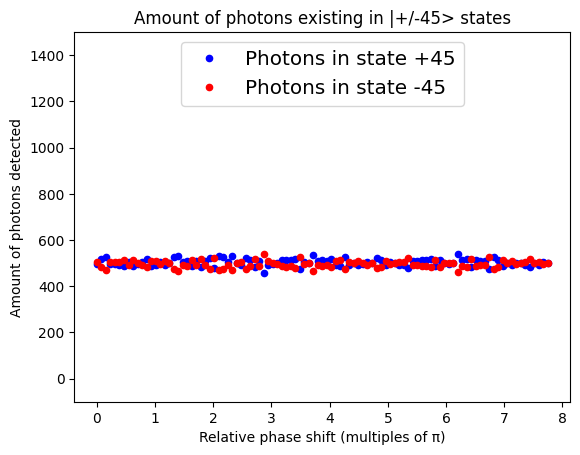

In [88]:
plt.plot(x_coords, y1_coords, 'b.', markersize=9, label='Photons in state +45')
plt.plot(x_coords, y2_coords, 'r.', markersize=9, label='Photons in state -45')
legend = plt.legend(loc='upper center', fontsize='x-large')
plt.ylim([-100, N_init + 500])
plt.xlabel('Relative phase shift (multiples of π)')
plt.ylabel('Amount of photons detected')
plt.title('Amount of photons existing in |+/-45> states');

In [81]:
psi_lower_after=y*psi_lower
psi_lower_after

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0. ]
 [-0.5]]

In [53]:
print(psi_upper)
print(psi_lower)
print(psi_upper + psi_lower)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.70710678]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
